# SAE architecture training-time comparison

Plots the results of `experiments/estimate_train_time.sh`, which trains one single SAE for a short
token budget (default 1M) on each **model × architecture** combo and records how long each took.

We compare **TopK / BatchTopK / Standard (L1) / JumpReLU** on **Qwen3-8B** and **gemma-3-4b-pt**, then:
1. show measured training-loop time for the short run,
2. project it up to a full token budget (`PROJECT_TOKENS`),
3. break down where the time goes (LLM forward vs SAE train) from the built-in profiler.

Run the experiment first:
```bash
./experiments/estimate_train_time.sh        # add GPU=1 / MODELS=... / ARCHS=... to taste
```

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# --- point this at an experiments/results/run_* dir; default = most recent ---
RESULTS_ROOT = Path("/wekafs/smerrill/efficient_sae/experiments/results")
RESULTS_DIR = None  # e.g. RESULTS_ROOT / "run_20260604_143000"

if RESULTS_DIR is None:
    runs = sorted(RESULTS_ROOT.glob("run_*"))
    assert runs, f"No run_* dirs under {RESULTS_ROOT}. Run experiments/estimate_train_time.sh first."
    RESULTS_DIR = runs[-1]
RESULTS_DIR = Path(RESULTS_DIR)

# Token budget to project the short benchmark up to (matches train_interactive.sh's 500M).
PROJECT_TOKENS = 500_000_000

print("Results dir   :", RESULTS_DIR)
print("Projecting to :", f"{PROJECT_TOKENS:,} tokens")

Results dir   : /wekafs/smerrill/efficient_sae/experiments/results/run_20260604_215426
Projecting to : 500,000,000 tokens


In [2]:
# --- load results.csv and enrich each row with its profiler timing_profile.json ---
ARCH_LABELS = {
    "topk": "TopK",
    "batchtopk": "BatchTopK",
    "standard": "Standard (L1)",
    "relu": "Standard (L1)",
    "jumprelu": "JumpReLU",
}
ARCH_ORDER = ["TopK", "BatchTopK", "Standard (L1)", "JumpReLU"]

df = pd.read_csv(RESULTS_DIR / "results.csv")

rows = []
for _, r in df.iterrows():
    rec = r.to_dict()
    tj = Path(str(r["timing_json"]))
    if tj.exists():
        prof = json.loads(tj.read_text())
        rec.update({f"prof_{k}": v for k, v in prof.items() if not isinstance(v, (dict, list))})
    rows.append(rec)
data = pd.DataFrame(rows)

data["arch_label"] = data["arch"].map(ARCH_LABELS).fillna(data["arch"])
data["ok"] = data["status"] == 0

# Training-loop time: profiler wall (excludes one-time model load) when available, else shell wall.
if "prof_wall_seconds" in data.columns:
    data["train_loop_s"] = data["prof_wall_seconds"].fillna(data["wall_seconds"])
else:
    data["train_loop_s"] = data["wall_seconds"]

def _safe_div(a, b):
    return a / b if b else float("nan")

data["tok_per_s_total"] = data.apply(lambda r: _safe_div(r["tokens"], r["wall_seconds"]), axis=1)
data["tok_per_s_train"] = data.apply(lambda r: _safe_div(r["tokens"], r["train_loop_s"]), axis=1)
data["proj_hours_total"] = PROJECT_TOKENS / data["tok_per_s_total"] / 3600
data["proj_hours_train"] = PROJECT_TOKENS / data["tok_per_s_train"] / 3600

# stable ordering for plots
data["arch_label"] = pd.Categorical(
    data["arch_label"], categories=ARCH_ORDER + [a for a in data["arch_label"].unique() if a not in ARCH_ORDER],
    ordered=True,
)
data = data.sort_values(["model", "arch_label"]).reset_index(drop=True)

n_fail = (~data["ok"]).sum()
if n_fail:
    print(f"⚠ {n_fail} run(s) failed (status != 0):")
    print(data.loc[~data["ok"], ["model", "arch_label", "status"]].to_string(index=False))
data

⚠ 4 run(s) failed (status != 0):
model    arch_label  status
 qwen          TopK     134
 qwen     BatchTopK     134
 qwen Standard (L1)     134
 qwen      JumpReLU     134


,model,model_name,arch,hook,d_in,d_sae,tokens,batch,ctx,status,...,prof_model_load_seconds,prof_checkpoint_pct_wall,prof_model_load_pct_wall,arch_label,ok,train_loop_s,tok_per_s_total,tok_per_s_train,proj_hours_total,proj_hours_train
0,gemma,google/gemma-3-4b-pt,topk,blocks.23.hook_resid_post,2560,40960,1000000,2048,1024,0,...,NaN,NaN,NaN,TopK,True,153.591939,6024.096386,6510.758369,23.055556,21.332214
1,gemma,google/gemma-3-4b-pt,batchtopk,blocks.23.hook_resid_post,2560,40960,1000000,2048,1024,0,...,NaN,NaN,NaN,BatchTopK,True,144.266292,6369.426752,6931.626151,21.805556,20.036985
2,gemma,google/gemma-3-4b-pt,standard,blocks.23.hook_resid_post,2560,40960,1000000,2048,1024,0,...,NaN,NaN,NaN,Standard (L1),True,143.754519,6410.256410,6956.303046,21.666667,19.965905
3,gemma,google/gemma-3-4b-pt,jumprelu,blocks.23.hook_resid_post,2560,40960,1000000,2048,1024,0,...,93.824769,5.672813,65.231762,JumpReLU,True,143.832952,6410.256410,6952.509725,21.666667,19.976799
4,qwen,Qwen/Qwen3-8B,topk,blocks.24.hook_resid_post,4096,65536,1000000,2048,1024,134,...,NaN,NaN,NaN,TopK,False,215.259146,4444.444444,4645.563348,31.250000,29.897104
5,qwen,Qwen/Qwen3-8B,batchtopk,blocks.24.hook_resid_post,4096,65536,1000000,2048,1024,134,...,NaN,NaN,NaN,BatchTopK,False,206.707397,4629.629630,4837.756234,30.000000,28.709361
6,qwen,Qwen/Qwen3-8B,standard,blocks.24.hook_resid_post,4096,65536,1000000,2048,1024,134,...,NaN,NaN,NaN,Standard (L1),False,196.085209,4854.368932,5099.823727,28.611111,27.234057
7,qwen,Qwen/Qwen3-8B,jumprelu,blocks.24.hook_resid_post,4096,65536,1000000,2048,1024,134,...,NaN,NaN,NaN,JumpReLU,False,201.969965,4739.336493,4951.231231,29.305556,28.051384


## Summary table

`train_loop_s` is the fit-loop wall time (excludes the one-time model load). `tok_per_s_train` and
`proj_hours_train` extrapolate that throughput to `PROJECT_TOKENS`. `forward_pct` / `sae_pct` come
from the built-in profiler and show how the compute time splits between the shared LLM forward pass
and the per-SAE training step.

In [3]:
summary_cols = {
    "model": "model",
    "arch_label": "arch",
    "ok": "ok",
    "tokens": "tokens",
    "wall_seconds": "wall_s (total)",
    "train_loop_s": "train_s (loop)",
    "tok_per_s_train": "tok/s",
    "proj_hours_train": f"proj_h @ {PROJECT_TOKENS/1e6:.0f}M",
}
if "prof_forward_pct_compute" in data.columns:
    summary_cols["prof_forward_pct_compute"] = "forward_%"
    summary_cols["prof_sae_pct_compute"] = "sae_%"

summary = data[list(summary_cols)].rename(columns=summary_cols)
summary = summary.round({"tok/s": 0, f"proj_h @ {PROJECT_TOKENS/1e6:.0f}M": 2,
                         "forward_%": 1, "sae_%": 1, "train_s (loop)": 1})
summary

,model,arch,ok,tokens,wall_s (total),train_s (loop),tok/s,proj_h @ 500M,forward_%,sae_%
0,gemma,TopK,True,1000000,166,153.6,6511.0,21.33,71.1,28.9
1,gemma,BatchTopK,True,1000000,157,144.3,6932.0,20.04,65.6,34.4
2,gemma,Standard (L1),True,1000000,156,143.8,6956.0,19.97,72.0,28.0
3,gemma,JumpReLU,True,1000000,156,143.8,6953.0,19.98,71.5,28.5
4,qwen,TopK,False,1000000,225,215.3,4646.0,29.90,71.3,28.7
5,qwen,BatchTopK,False,1000000,216,206.7,4838.0,28.71,65.6,34.4
6,qwen,Standard (L1),False,1000000,206,196.1,5100.0,27.23,72.4,27.6
7,qwen,JumpReLU,False,1000000,211,202.0,4951.0,28.05,71.7,28.3


## Measured training-loop time (short run)

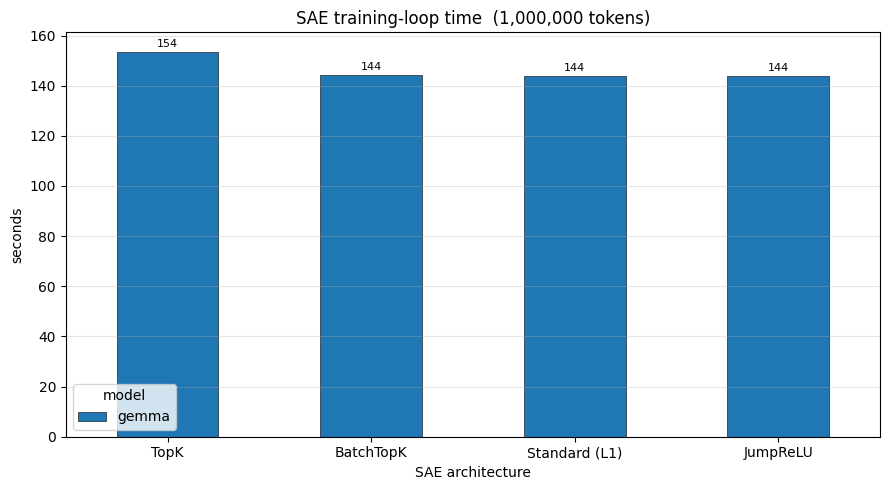

In [4]:
def grouped_bar(metric, title, ylabel, fmt="%.0f"):
    ok = data[data["ok"]]
    if ok.empty:
        print("No successful runs to plot.")
        return
    pivot = ok.pivot_table(index="arch_label", columns="model", values=metric, observed=True)
    ax = pivot.plot(kind="bar", figsize=(9, 5), rot=0, edgecolor="black", linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel("SAE architecture")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="model")
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()
    return pivot


tokens = int(data["tokens"].iloc[0])
grouped_bar("train_loop_s", f"SAE training-loop time  ({tokens:,} tokens)", "seconds");

## Projected full-run time

Extrapolates the measured throughput up to `PROJECT_TOKENS` (linear; ignores warmup/load amortization,
so treat it as a rough estimate).

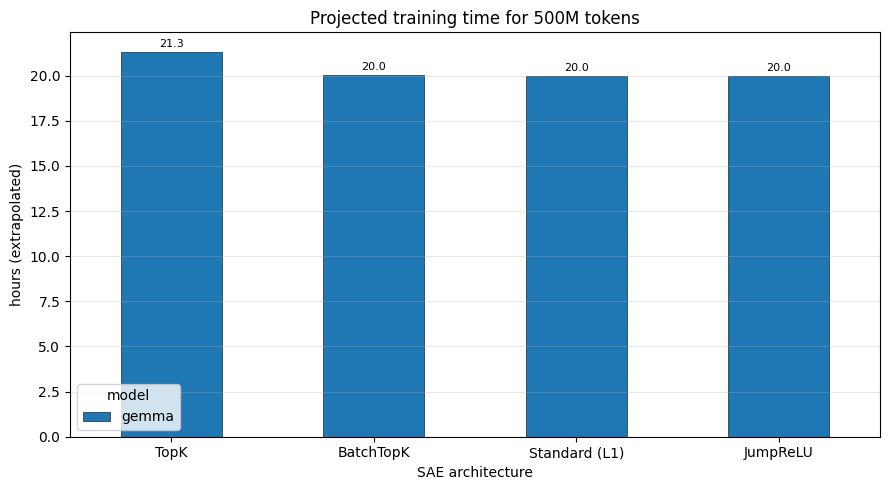

In [5]:
grouped_bar(
    "proj_hours_train",
    f"Projected training time for {PROJECT_TOKENS/1e6:.0f}M tokens",
    "hours (extrapolated)",
    fmt="%.1f",
);

## Where the time goes — full wall-clock breakdown

From the built-in profiler (`timing_profile.json`): **model load** (one-time LLM load onto the GPU),
**LLM forward** (shared activation generation), **SAE train** (per-SAE fwd+bwd+optimizer),
**checkpoint I/O** (weights + optimizer state to disk), and **other** (norm-est, per-step bookkeeping).
The LLM forward and model load are shared work that doesn't depend on the SAE architecture, so
differences between archs mostly come from the SAE-train portion. On these short runs the one-time
model load is a large fixed slice; on a full run it becomes negligible.

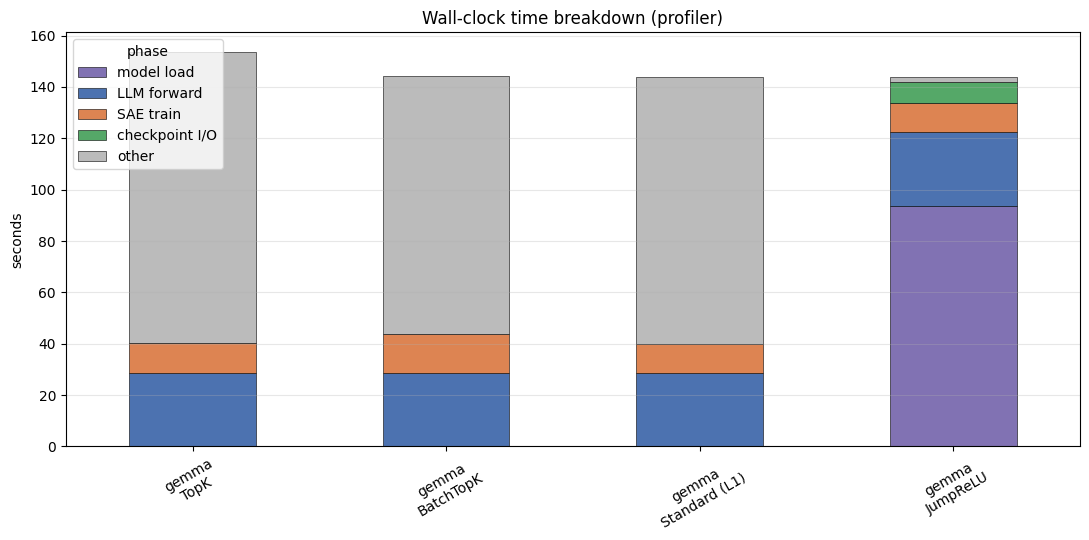

In [6]:
split_cols = ["prof_model_load_seconds", "prof_forward_seconds", "prof_sae_seconds",
              "prof_checkpoint_seconds", "prof_other_seconds"]
phase_names = ["model load", "LLM forward", "SAE train", "checkpoint I/O", "other"]
phase_colors = ["#8172B3", "#4C72B0", "#DD8452", "#55A868", "#BBBBBB"]
ok = data[data["ok"]].copy()

present = [c for c in split_cols if c in ok.columns]
if present and ok[present].notna().any().any():
    for c in split_cols:
        if c not in ok.columns:
            ok[c] = 0.0
    ok["label"] = ok["model"].astype(str) + "\n" + ok["arch_label"].astype(str)
    sub = ok.set_index("label")[split_cols].fillna(0.0).copy()
    sub.columns = phase_names
    ax = sub.plot(kind="bar", stacked=True, figsize=(11, 5.5), rot=30,
                  color=phase_colors, edgecolor="black", linewidth=0.4)
    ax.set_title("Wall-clock time breakdown (profiler)")
    ax.set_ylabel("seconds")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="phase")
    plt.tight_layout()
    plt.show()
else:
    print("No profiler timing_profile.json data found — re-run the experiment with profiling on "
          "(it is on by default; pass nothing special).")